In [ ]:
"""
================================================================================
 LLM-Driven Textual Poisoning Attacks aginast CF Using Side Textual Information
================================================================================

This script demonstrates generation of textual attacks using LLMs, that are used in our works
against CF models using Side Textual Information, and Retrieval Augmented Generation (RAG).
Refer to the accompanying paper for the theoretical framework and experiments on
'promotion' or 'demotion' of target items using four attacker strategies:
(1) Emotional, (2) Neighbor, (3) Chain, and (4) Trigger.

Code References:
 - Contains standard data loading for MovieLens
 - Defines textual-attack functions using LLM calls (e.g., ChatGPT/OpenAI)
 - Applies minimal text edits with semantic constraints
 - Handles single-threaded ("normal") and multi-threaded ("parallel") versions

Please see the paper and the README.md for details on usage, parameters,
and how to interpret or extend these textual poisoning attacks.
"""


'\n================================================================================\n LLM-Driven Textual Poisoning Attacks aginast CF Using Side Textual Information\n================================================================================\n\nThis script demonstrates generation of textual attacks using LLMs, that are used in our works\nagainst CF models using Side Textual Information, and Retrieval Augmented Generation (RAG).\nRefer to the accompanying paper for the theoretical framework and experiments on\n\'promotion\' or \'demotion\' of target items using four attacker strategies:\n(1) Emotional, (2) Neighbor, (3) Chain, and (4) Trigger.\n\nCode References:\n - Contains standard data loading for MovieLens\n - Defines textual-attack functions using LLM calls (e.g., ChatGPT/OpenAI)\n - Applies minimal text edits with semantic constraints\n - Handles single-threaded ("normal") and multi-threaded ("parallel") versions\n\nPlease see the paper and the README.md for details on usage

In [ ]:
import os

api_key = ""
os.environ["OPENAI_API_KEY"] = api_key

In [ ]:
ds_name = "ml_latest_small"  #"ml_latest_small" # "lfm360k" #"ml_latest_small" #"ml_latest_small" #"ml_latest_small"
use_preComputedSimilarities = 'yes'
data_aug_with_rationale = "no"
flag_usePrecomputedAttack = "No"
promote_demote_label = "promote"
useSampledDS = False
attack_ratio = 0.10  # number of items attacks (e.g., 10% of items)
run_parallel_version = True
neighbor = 5
flag_run_demo = False



In [ ]:
!pip install openai==0.28.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.61.1
    Uninstalling openai-1.61.1:
      Successfully uninstalled openai-1.61.1


In [ ]:
import requests
import pandas as pd
import ast
import openai

def download_csv(url, csv_file_name):
    """
    Download a CSV file from a URL and save it locally.

    Parameters:
    url (str): The URL to download the file from.
    csv_file_name (str): The local filename to save the downloaded file.

    Returns:
    bool: True if download succeeds, False otherwise.
    """
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(csv_file_name, "wb") as file:
            for chunk in response.iter_content(chunk_size=128):
                file.write(chunk)
        print(f"{csv_file_name} downloaded successfully.")
        return True
    print(f"Failed to download the file. Status code: {response.status_code}")
    return False

# Function to load a CSV file (compressed or uncompressed)
def load_csv_file(file_path):
    """
    Load a CSV file, handling both compressed (.csv.gz) and uncompressed (.csv) formats.

    Parameters:
    - file_path (str): Path to the CSV file.

    Returns:
    - pd.DataFrame: Loaded DataFrame.
    """
    if file_path.endswith('.csv.gz'):
        return pd.read_csv(file_path, compression='gzip')
    elif file_path.endswith('.csv'):
        return pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")

def load_data_ml():
    """
    Download and load datasets for ratings, items, and tags, merging tags into items.

    Returns:
    tuple: DataFrames for ratings, items, tags, and items with merged tags.
    """
    urls = {
        "ratings": "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/e3a18487525d3ae8ec19b39959c1a881c383e1a8/ml_latest/df_ratings_ml-latest-small.csv",
        "items": "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/e3a18487525d3ae8ec19b39959c1a881c383e1a8/ml_latest/df_item_ml-latest-small.csv",
        "tags": "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/21484da12f01263fc0194d12c63d796628f84137/ml_latest/df_tags_ml-latest-small.csv"
    }
    files = {key: f"df_{key}_ml-latest-small.csv" for key in urls}

    if all(download_csv(urls[key], files[key]) for key in urls):
        df_ratings = pd.read_csv(files["ratings"], names=['userId', 'itemId', 'rating', 'timestamp'], header=0, low_memory=False)
        df_items = pd.read_csv(files["items"], low_memory=False)
        df_tags = pd.read_csv(files["tags"], low_memory=False)

        for df, col in [(df_ratings, 'userId'), (df_ratings, 'itemId'), (df_items, 'itemId'), (df_tags, 'itemId'), (df_tags, 'userId')]:
            df[col] = df[col].astype(int)

        tags_grouped = df_tags.groupby('itemId')['tag'].apply(list).reset_index()
        df_items_merged = pd.merge(df_items, tags_grouped, on='itemId', how='left')
        df_items_merged['tag'] = df_items_merged['tag'].apply(lambda x: x if isinstance(x, list) else [])

        print("Datasets loaded successfully.")
        return df_ratings, df_items_merged, df_tags

    print("Failed to download one or more datasets.")
    return None, None, None, None

def load_data_lastfm(n=10):
    """
    Loads the LFM-360K dataset from GitHub, downloads if needed.
    Then converts 'plays' into a rating [0..n] using the formula:
        rating(u,i) = n * F(playcount_u_i),
    where F(playcount_u_i) is the empirical CDF of that item’s
    playcount among the user’s listened items.

    Returns:
        df_ratings (DataFrame): columns [userId, itemId, rating]
        df_items   (DataFrame): columns [itemId, artist, tags]
    """
    url = "https://raw.githubusercontent.com/yasdel/RecSys_Datasets/main/lfm-360K/lastFM360k_trg_user_40000_trg_Artist_4000.csv"
    out_file = "lastFM360k_trg_user_40000_trg_Artist_4000.csv"

    success = download_csv(url, out_file)
    if not success:
        return None, None

    # Load
    df = pd.read_csv(out_file, low_memory=False, index_col = 0)
    display(df)
    # Rename columns so we can unify them with typical 'itemId', 'rating'
    df.rename(columns={'artistId': 'itemId', 'plays': 'playcount'}, inplace=True)

    # Construct a ratings DataFrame
    df_ratings = df[['userId', 'itemId', 'playcount']].copy()

    # === Compute the user-specific CDF-based rating ===
    # We group by user, compute the rank of each playcount among that user's items
    # so rating = n * ( rank / total_items_in_user_profile ).
    # We do rank(method='min') for tie handling, you can also do 'dense' if you prefer.

    df_ratings['rank_in_user'] = df_ratings.groupby('userId')['playcount'] \
                                           .rank(method='min', ascending=True)

    # Number of items each user has
    df_ratings['count_in_user'] = df_ratings.groupby('userId')['playcount'] \
                                            .transform('count')

    # Empirical CDF: fraction of items that have playcount <= current playcount
    # We'll do (rank_in_user / count_in_user).
    # Then multiply by n to get a [0..n] rating.
    df_ratings['rating'] = (df_ratings['rank_in_user'] / df_ratings['count_in_user']) * n

    # Now we only keep userId, itemId, rating
    df_ratings = df_ratings[['userId', 'itemId', 'rating']].copy()

    # Construct an items DataFrame
    df_items = df[['itemId', 'artist', 'tags']].drop_duplicates().copy()

    # Convert 'tags' from string to list if needed
    df_items['tags'] = df_items['tags'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
    )

    print("Last.fm dataset loaded and playcounts converted to rating scale [0..{}].".format(n))
    return df_ratings, df_items

def print_statistics(data):
    """
    Print dataset statistics including total interactions, unique users, items, and interaction ratios.

    Parameters:
    data (pd.DataFrame): DataFrame with 'userId' and 'itemId' columns.
    """
    display(data)
    total_interactions = data.shape[0]
    unique_users = data['userId'].nunique()
    unique_items = data['itemId'].nunique()

    print("--------------------------")
    print("The Dataset Overview:")
    print(f" - Total Interactions: {total_interactions}")
    print(f" - |U|: {unique_users}")
    print(f" - |I|: {unique_items}")
    print(f" - |R|/|U|: {total_interactions / unique_users:.2f}")
    print(f" - |R|/|I|: {total_interactions / unique_items:.2f}")
    print(f" - |R|/(|U|*|I|): {total_interactions / (unique_users * unique_items):.10f}")
    print("--------------------------")

def apply_interaction_limits(data, min_interactions, max_interactions, user_col, item_col):
    """
    Filter users based on interaction limits.

    Parameters:
    data (pd.DataFrame): DataFrame with interactions.
    min_interactions (int): Minimum number of interactions per user.
    max_interactions (int): Maximum number of interactions per user.
    user_col (str): Column name for users.
    item_col (str): Column name for items.

    Returns:
    pd.DataFrame: Filtered DataFrame.
    """
    interaction_counts = data[user_col].value_counts()
    users_to_keep = interaction_counts[(interaction_counts >= min_interactions) & (interaction_counts <= max_interactions)].index
    return data[data[user_col].isin(users_to_keep)]

display("Original Dataset Statistics:")



# Example: Download and load datasets
#df_ratings, df_items, df_tags = load_datasets()
#print_statistics(df_ratings)


# Main logic:
if ds_name == "ml_latest_small":
    df_ratings, df_items, df_tags = load_data_ml()  # returns three DFs for ML
    display(df_ratings.head())
    display(df_items.head())
    print_statistics(df_ratings)
    # Load the file from the local directory
    if data_aug_with_rationale.lower == "no":
      fileName = "enriched_descriptions_dataset_ml_latest_small_gpt-4o-mini_with_rationale_No.csv.gz"
    else:
      fileName = "enriched_descriptions_dataset_ml_latest_small_gpt-4o-mini_with_rationale_Yes.csv.gz"
    print(f'{fileName} loaded ... from dataset {ds_name}')
    df_items =  pd.read_csv("https://github.com/yasdel/GenRecSys-LLM-DataAugmentation/raw/main/Data/" + fileName, compression='gzip')
elif ds_name == "lfm360k":
    df_ratings, df_items = load_data_lastfm(n=10)       # returns two DFs for Last.fm
    if data_aug_with_rationale.lower == "no":
      fileName = "enriched_desc_ds_lfm360k_gpt-4o-mini_with_rationale_No.csv.gz"
    else:
      fileName = "enriched_desc_ds_lfm360k_gpt-4o-mini_with_rationale_Yes.csv.gz"
    print(f'{fileName} loaded ... from dataset {ds_name}')
    df_items =  pd.read_csv("https://github.com/yasdel/GenRecSys-LLM-DataAugmentation/raw/main/Data/" + fileName, compression='gzip')
    display(df_ratings.head())
    display(df_items.head())
    print_statistics(df_ratings)
else:
    raise ValueError("Unknown dataset_flag specified.")


# Check if 'tag' exists, then rename to 'tags'
if 'tags' in df_items.columns:
    df_items.rename(columns={'tags': 'tag'}, inplace=True)
    display(df_items.head())

# Example: Apply interaction limits if datasets are loaded
if ds_name == "ml_latest_small" and df_ratings is not None and useSampledDS==True:
    MIN_INTERACTIONS, MAX_INTERACTIONS = 30, 50
    df_ratings_filtered = apply_interaction_limits(df_ratings, MIN_INTERACTIONS, MAX_INTERACTIONS, 'userId', 'itemId')

    display("Filtered Dataset Statistics:")
    print_statistics(df_ratings_filtered)

    sampled_item_ids = df_ratings_filtered['itemId'].unique()
    df_items_sampled = df_items[df_items['itemId'].isin(sampled_item_ids)]

    display("Sampled items with tags:")
    display(df_items_sampled.head())

    df_items = df_items_sampled.copy()
    df_ratings = df_ratings_filtered.copy()


'Original Dataset Statistics:'

df_ratings_ml-latest-small.csv downloaded successfully.
df_items_ml-latest-small.csv downloaded successfully.
df_tags_ml-latest-small.csv downloaded successfully.
Datasets loaded successfully.


,userId,itemId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,itemId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[pixar, pixar, fun]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[fantasy, magic board game, Robin Williams, game]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[moldy, old]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,[]
4,5,Father of the Bride Part II (1995),Comedy,"[pregnancy, remake]"


,userId,itemId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


--------------------------
The Dataset Overview:
 - Total Interactions: 100836
 - |U|: 610
 - |I|: 9724
 - |R|/|U|: 165.30
 - |R|/|I|: 10.37
 - |R|/(|U|*|I|): 0.0169996831
--------------------------
enriched_descriptions_dataset_ml_latest_small_gpt-4o-mini_with_rationale_Yes.csv.gz loaded ... from dataset ml_latest_small


In [ ]:
import pandas as pd
# Visualize the popularity classes
import matplotlib.pyplot as plt
import seaborn as sns

def assign_popularity_class(user_item_df, rating_col='rating'):
    """
    Assign popularity classes to items based on their number of ratings.

    Parameters:
    - user_item_df (pd.DataFrame): DataFrame with columns ['userId', 'itemId', 'rating', 'time_stamp'].
    - rating_col (str): The column used to count ratings (default is 'rating').

    Returns:
    - pd.DataFrame: A new DataFrame with columns ['itemId', 'pop_class'] where:
        - pop_class = 0 (popular/head),
        - pop_class = 1 (mid-tail),
        - pop_class = 2 (long-tail).
    """
    # 1. Calculate the number of ratings per item
    item_rating_counts = user_item_df.groupby('itemId')[rating_col].count().reset_index()
    item_rating_counts.columns = ['itemId', 'rating_count']

    # 2. Define thresholds for popularity classes
    # Top 20%: class 0 (popular/head)
    # Middle 30%: class 1 (mid-tail)
    # Bottom 50%: class 2 (long-tail)
    q_pop = item_rating_counts['rating_count'].quantile(0.80)  # Top 20%
    q_mid = item_rating_counts['rating_count'].quantile(0.50)  # Middle 50%

    # 3. Assign classes based on thresholds
    def classify_popularity(count):
        if count >= q_pop:
            return 0  # popular/head
        elif count >= q_mid:
            return 1  # mid-tail
        else:
            return 2  # long-tail

    item_rating_counts['pop_class'] = item_rating_counts['rating_count'].apply(classify_popularity)

    # 4. Return the resulting DataFrame with unique itemId and pop_class
    return item_rating_counts[['itemId', 'pop_class']]


def assign_popularity_class_based_on_rating_percentage(user_item_df, rating_col='rating'):
    """
    Assign popularity classes to items based on their contribution to the total number of ratings.
    Thresholds are decided based on cumulative percentages of total ratings contributed by items.

    Parameters:
    - user_item_df (pd.DataFrame): DataFrame with columns ['userId', 'itemId', 'rating', 'time_stamp'].
    - rating_col (str): The column used to count ratings (default is 'rating').

    Returns:
    - pd.DataFrame: A new DataFrame with columns ['itemId', 'pop_class'] where:
        - pop_class = 0 (popular/head),
        - pop_class = 1 (mid-tail),
        - pop_class = 2 (long-tail).
    """
    # 1. Calculate the number of ratings per item
    item_rating_counts = user_item_df.groupby('itemId')[rating_col].count().reset_index()
    item_rating_counts.columns = ['itemId', 'rating_count']

    # 2. Sort items by rating_count in descending order
    item_rating_counts = item_rating_counts.sort_values(by='rating_count', ascending=False)

    # 3. Calculate the cumulative percentage of ratings
    total_ratings = item_rating_counts['rating_count'].sum()
    item_rating_counts['cumulative_percentage'] = item_rating_counts['rating_count'].cumsum() / total_ratings * 100

    # 4. Define thresholds based on cumulative percentages
    # Popular (Head): Top 50% of ratings
    # Mid-Tail: Next 30% of ratings
    # Long-Tail: Remaining items
    def classify_popularity(cumulative_percentage):
        if cumulative_percentage <= 50:
            return 0  # Popular/Head
        elif cumulative_percentage <= 80:
            return 1  # Mid-Tail
        else:
            return 2  # Long-Tail

    # 5. Assign popularity class based on cumulative percentage
    item_rating_counts['pop_class'] = item_rating_counts['cumulative_percentage'].apply(classify_popularity)

    # 6. Return the resulting DataFrame with unique itemId and pop_class
    return item_rating_counts[['itemId', 'pop_class']]


def count_ratings_per_class(user_item_df, popularity_df):
    """
    Count the total number of ratings in each popularity class.

    Parameters:
    - user_item_df (pd.DataFrame): DataFrame with columns ['userId', 'itemId', 'rating', 'time_stamp'].
    - popularity_df (pd.DataFrame): DataFrame with columns ['itemId', 'pop_class'].

    Returns:
    - pd.DataFrame: DataFrame with columns ['pop_class', 'total_ratings'].
    """
    # Merge the popularity classes with the user-item data
    merged_df = user_item_df.merge(popularity_df, on="itemId")

    # Group by popularity class and count the number of ratings
    ratings_per_class = (
        merged_df.groupby("pop_class")["rating"].count().reset_index(name="total_ratings")
    )

    # Sort by popularity class for better readability
    ratings_per_class = ratings_per_class.sort_values(by="pop_class").reset_index(drop=True)
    return ratings_per_class


# Sample User-Item Matrix
data = {
    'userId': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'itemId': [101, 102, 103, 101, 104, 102, 103, 101, 105, 104],
    'rating': [4, 5, 3, 5, 4, 4, 5, 3, 2, 4],
    'time_stamp': [1630001, 1630002, 1630003, 1630004, 1630005, 1630006, 1630007, 1630008, 1630009, 1630010],
}

df_ratings_sample = pd.DataFrame(data)

popularity_df = assign_popularity_class(df_ratings_sample)
ratings_per_class_df = count_ratings_per_class(df_ratings_sample, popularity_df)
print(ratings_per_class_df)


##############
popularity_df = assign_popularity_class_based_on_rating_percentage(df_ratings_sample)
ratings_per_class_df = count_ratings_per_class(df_ratings_sample, popularity_df)
print(ratings_per_class_df)


############## on real_ds
popularity_df = assign_popularity_class(df_ratings)
ratings_per_class_df = count_ratings_per_class(df_ratings, popularity_df)
print(ratings_per_class_df)


popularity_df = assign_popularity_class_based_on_rating_percentage(df_ratings)
ratings_per_class_df = count_ratings_per_class(df_ratings, popularity_df)
print(ratings_per_class_df)


df_items = pd.merge(df_items, popularity_df, on='itemId', how='inner')
display(df_items)



   pop_class  total_ratings
0          0              3
1          1              6
2          2              1
   pop_class  total_ratings
0          0              5
1          1              2
2          2              3
   pop_class  total_ratings
0          0          77942
1          1          16852
2          2           6042
   pop_class  total_ratings
0          0          50408
1          1          30258
2          2          20170


,itemId,title,genres,tag,enriched_description,pop_class
0,19,Ace Ventura: When Nature Calls (1995),Comedy,[],"In the uproarious sequel ""Ace Ventura: When Na...",0
1,42,Dead Presidents (1995),Action|Crime|Drama,[],"""Dead Presidents"" is a gripping 1995 film that...",2
2,41,Richard III (1995),Drama|War,['Shakespeare'],"""Richard III"" (1995), directed by Richard Lonc...",1
3,23,Assassins (1995),Action|Crime|Thriller,[],"In the heart-pounding action thriller ""Assassi...",1
4,5,Father of the Bride Part II (1995),Comedy,"['pregnancy', 'remake']","In the delightful sequel ""Father of the Bride ...",0
...,...,...,...,...,...,...
9719,190213,John From (2015),Drama,[],"""John From"" is a poignant drama that delves in...",2
9720,190221,Hommage à Zgougou (et salut à Sabine Mamou) (2...,Documentary,[],"""Hommage à Zgougou (et salut à Sabine Mamou)"" ...",2
9721,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,[],"In the vibrant and chaotic world of ""Bungo Str...",2
9722,190219,Bunny (1998),Animation,[],"In the whimsical world of ""Bunny,"" a 1998 anim...",2


In [ ]:
if use_preComputedSimilarities.lower() == 'no':
  from sentence_transformers import SentenceTransformer
  from sklearn.metrics.pairwise import cosine_similarity
  import numpy as np

  from sentence_transformers import SentenceTransformer
  from sklearn.metrics.pairwise import cosine_similarity
  import numpy as np

  def compute_item_similarities(df_items, text_column, pop_class_column, top_k=200, model_name='all-MiniLM-L6-v2'):
      """
      Compute embeddings and similarities between items using a modern embedding model (SentenceTransformer).
      Precompute two columns:
      (1) sim_items_200: Item IDs of the most similar 100 items (of different classes).
      (2) sim_items_200_class_based: Item IDs of the most similar 100 items divided into 3 classes (popular, mid-tail, long-tail).

      Parameters:
      - df_items (pd.DataFrame): DataFrame containing item data, including text for embeddings and popularity classes.
      - text_column (str): Column to use for generating embeddings (e.g., 'enriched_description').
      - pop_class_column (str): Column indicating the popularity class (e.g., 'pop_class').
      - top_k (int): Number of most similar items to store.
      - model_name (str): Name of the SentenceTransformer model.

      Returns:
      - pd.DataFrame: Updated DataFrame with `sim_items_200` and `sim_items_200_class_based` columns.
      """
      # Ensure the text_column contains strings (e.g., join lists into strings if necessary)
      if isinstance(df_items[text_column].iloc[0], list):
          df_items[text_column] = df_items[text_column].apply(lambda x: " ".join(x))

      # Load the SentenceTransformer model
      model = SentenceTransformer(model_name)

      # Compute embeddings for the text column
      embeddings = model.encode(df_items[text_column].tolist(), convert_to_tensor=True)

      # Compute cosine similarity matrix
      similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

      # Initialize columns for storing results
      df_items['sim_items_200'] = ""
      df_items['sim_items_200_class_based'] = ""

      # Iterate over each item to compute top-K similar items
      for idx, row in df_items.iterrows():
          # Get similarity scores for the current item
          similarity_scores = similarity_matrix[idx]

          # Get the top-K most similar item indices (excluding itself)
          similar_indices = np.argsort(similarity_scores)[::-1][1:top_k + 1]
          similar_items = df_items.iloc[similar_indices]['itemId'].tolist()

          # Store most similar 100 items (all classes)
          df_items.at[idx, 'sim_items_200'] = similar_items

          # Divide similar items into classes
          similar_items_by_class = {0: [], 1: [], 2: []}
          for sim_idx in similar_indices:
              item_id = df_items.iloc[sim_idx]['itemId']
              item_class = df_items.iloc[sim_idx][pop_class_column]
              similar_items_by_class[item_class].append(item_id)

          # Keep only top-K items per class and sort them
          for cls in similar_items_by_class:
              similar_items_by_class[cls] = sorted(similar_items_by_class[cls][:top_k])

          # Store the class-based dictionary
          df_items.at[idx, 'sim_items_200_class_based'] = similar_items_by_class

      return df_items

# Example Usage
# Assuming df_items has columns 'itemId', 'tag', and 'pop_class'
#df_items = compute_item_similarities(df_items, text_column='tag', pop_class_column='pop_class', top_k=100)
#print(df_items.head())

In [ ]:
url = "https://github.com/yasdel/GenRecSys-LLM-DataAugmentation/raw/main/Data/"
if use_preComputedSimilarities.lower() == 'yes':
  if ds_name == 'ml_latest_small':
    file_path = url + "enriched_descriptions_dataset_ml_latest_small_gpt-4o-mini_with_rationale_No_with_neigbors.csv.gz"
  elif ds_name == 'lfm360k':
    file_path = url + "enriched_desc_ds_lfm360k_gpt-4o-mini_with_rationale_No_with_neigbors.csv.gz"
  else:
    raise ValueError(f"Unknown dataset name: {ds_name}")
  df_items = load_csv_file(file_path)
else:
  df_items = compute_item_similarities(df_items, text_column='enriched_description', pop_class_column='pop_class', top_k=200)
  fileName = fileName.replace('.', '_with_neigbors.', 1)
  df_items.to_csv(fileName,
                index=False,
                compression="gzip")
display(df_items)


if useSampledDS == True:
  df_items = df_items[df_items['itemId'].isin(sampled_item_ids)]
  display(df_items_sampled)


,itemId,title,genres,tag,enriched_description,pop_class,sim_items_200,sim_items_200_class_based
0,7,Sabrina (1995),Comedy|Romance,['remake'],**Sabrina (1995)** is a delightful romantic co...,0,"[915, 360, 6899, 345, 2155, 295, 68, 287, 1549...","{0: [186, 500, 555, 597, 1197, 1569, 1777, 229..."
1,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller,[],**Money Train (1995)** is a thrilling blend of...,1,"[1604, 5454, 124859, 3537, 2391, 3384, 2344, 4...","{0: [1, 21, 172, 296, 333, 434, 778, 1073, 122..."
2,36,Dead Man Walking (1995),Crime|Drama,"['death penalty', 'Nun']",**Dead Man Walking (1995)** is a poignant and ...,0,"[726, 7883, 81, 54787, 4160, 336, 1114, 3258, ...","{0: [151, 253, 282, 288, 377, 587, 1246, 1923,..."
3,17,Sense and Sensibility (1995),Drama|Romance,['Jane Austen'],**Sense and Sensibility (1995)** is a beautifu...,0,"[7669, 28, 26958, 40629, 70521, 2027, 46976, 1...","{0: [34, 236, 261, 357, 497, 500, 509, 1674, 2..."
4,3,Grumpier Old Men (1995),Comedy|Romance,"['moldy', 'old']",**Grumpier Old Men (1995)** is a delightful se...,0,"[3450, 1179, 184349, 1929, 100083, 3258, 1473,...","{0: [357, 410, 1278, 1721, 2003, 2324, 2407, 4..."
...,...,...,...,...,...,...,...,...
9719,189043,Boundaries (2018),Comedy|Drama,[],**Boundaries (2018)** is a heartwarming blend ...,2,"[6886, 32584, 161032, 3497, 8380, 99415, 2766,...","{0: [186, 762, 3471, 3948, 5377, 8784, 8949], ..."
9720,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,[],**No Game No Life: Zero (2017)** is a visually...,2,"[8012, 27537, 27480, 63276, 31437, 27722, 7118...","{0: [44, 1274, 1625, 2019, 2161, 59784, 91500]..."
9721,190213,John From (2015),Drama,[],**John From (2015)** is a poignant and evocati...,2,"[144478, 8183, 6111, 7285, 4074, 2915, 7767, 1...","{0: [2324, 2580, 2915, 5377], 1: [29, 58, 175,..."
9722,188833,The Man Who Killed Don Quixote (2018),Adventure|Comedy|Fantasy,[],**The Man Who Killed Don Quixote (2018)** is a...,2,"[6062, 3993, 3431, 26750, 132046, 176, 5938, 9...","{0: [3, 165, 1080, 1199, 1213, 1407, 2000, 200..."


In [ ]:
import math
import random
import openai
import time
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
import requests
from requests.exceptions import ChunkedEncodingError, ConnectionError
from openai.error import APIError, RateLimitError, Timeout, ServiceUnavailableError
from concurrent.futures import ThreadPoolExecutor, as_completed
import json

openai.api_key = os.getenv("OPENAI_API_KEY")  # Replace with your API key if needed



def call_llm_api_batch(
    prompts,
    model="gpt-4o-mini",
    temperature=0.2,
    max_retries=8,
    backoff=2,
    max_workers=20
):
    """
    Process multiple prompts concurrently, each with robust retry
    handling for chunked/connection errors and other transient issues.

    This function returns a list of responses, one per prompt, in
    the same order as the input.

    Parameters
    ----------
    prompts : List[str]
        A list of text prompts to be sent to the LLM.
    model : str
        Model name to be used (e.g., 'gpt-4o-mini').
    temperature : float
        LLM generation temperature (0..1).
    max_retries : int
        Maximum attempts to call the API for each prompt.
    backoff : int
        Exponential backoff base (2^attempt).
    max_workers : int
        Number of threads in the pool for parallel calls.

    Returns
    -------
    List[str]
        A list of LLM responses, in the same order as 'prompts'.
        If a prompt fails all retries, its entry in the result list
        will be None (or raise an Exception if you prefer).
    """

    def worker_fn(prompt, idx):
        """
        Helper function that calls `call_llm_api_with_retry`
        for a single prompt, capturing both the response and index.
        """
        resp_text = call_llm_api_with_retry(
            prompt=prompt,
            model=model,
            temperature=temperature,
            max_retries=max_retries,
            backoff=backoff
        )
        return (idx, resp_text)

    results = [None] * len(prompts)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_index = {}
        for i, pr in enumerate(prompts):
            future = executor.submit(worker_fn, pr, i)
            future_to_index[future] = i

        for future in as_completed(future_to_index):
            idx = future_to_index[future]
            try:
                out_idx, out_text = future.result()
                results[out_idx] = out_text
            except Exception as e:
                print(f"[ERROR] Prompt {idx} failed permanently after retries: {e}")
                results[idx] = None  # or handle differently if needed

    return results


def call_llm_api_with_retry(
    prompt: str,
    model="gpt-4o-mini",
    temperature: float = 0.2,
    max_retries: int =8,
    backoff: int = 2
) -> str:
    """
    Make a single LLM API call with a robust retry mechanism.

    This function addresses ChunkedEncodingError by:
      - Catching chunked/connection issues and other typical
        transient OpenAI or requests-related errors.
      - Retrying up to 'max_retries' times, with an exponential
        backoff (sleeping 2^attempt seconds).

    Parameters
    ----------
    prompt : str
        The user's text prompt for the LLM.
    model : str
        Model name (e.g., "gpt-4o-mini").
    temperature : float
        LLM generation temperature.
    max_retries : int
        Maximum attempts before giving up.
    backoff : int
        Base exponent for backoff (e.g., 2 -> 2^attempt).

    Returns
    -------
    str
        The LLM's text response, or raises Exception if all
        attempts fail.
    """
    attempt = 0
    system_instructions = (
        "You are a helpful assistant. Follow the user's instructions and constraints precisely. "
        "When neighbor text is provided, you MUST incorporate at least a few exact phrases or sentences "
        "from the neighbor text into the final response, without paraphrasing that phrase. "
        "You must still obey all constraints about maximum changes to the original text. "
        "Keep the final output coherent and grammatical."
    )

    while True:
        try:
            response = openai.ChatCompletion.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_instructions},
                    {"role": "user", "content": prompt}
                ],
                temperature=temperature,
            )
            return response["choices"][0]["message"]["content"]

        except (APIError, RateLimitError, Timeout, ServiceUnavailableError,
                json.JSONDecodeError, ChunkedEncodingError, ConnectionError) as e:
            attempt += 1
            if attempt >= max_retries:
                print(f"[ERROR] LLM API failed after {attempt} attempts. Raising exception: {e}")
                raise
            wait_time = backoff ** attempt
            print(f"[WARNING] LLM API error: {e}. Retrying in {wait_time}s (attempt {attempt}/{max_retries})...")
            time.sleep(wait_time)

        except Exception as ex:
            print("[ERROR] Unexpected exception in call_llm_api_with_retry:", ex)
            raise


def generate_semantic_emotional_edit(
    original_text: str,
    direction: str = "promote",
    max_change_ratio: float = 0.1
) -> str:
    """
    Rewrite `original_text` to be more (promote) or less (demote) appealing,
    limiting changes to `max_change_ratio` of the text length.
    """
    words = original_text.split()
    max_changes = math.floor(len(words) * max_change_ratio)

    # ===== UPDATED PROMOTION PROMPT =====
    if direction.lower() == "promote":
        instruction_text = (
            "Rewrite the description so that it appears SIGNIFICANTLY more appealing to strongly increase its visibility on our recommender system. "
            "Use vibrant, emotionally charged or persuasive wording. Rearrange or restructure the text if needed. "
            "Add a short bullet list of at least two 'positive highlights' that emphasize the best aspects. "
            f"Do not change more than {100*max_change_ratio}% of the text."
        )
    else:
        instruction_text = (
            "Rewrite the description to be less appealing in order to decrease its visibility on our recommender system. "
            "Use subtle negative or lukewarm language while maintaining coherence. "
            f"Do not change more than {100*max_change_ratio}% of the text."
        )

    prompt = f"""
    Original Description:
    {original_text}

    Task:
    {instruction_text}

    Constraints:
    - Up to {max_changes} words can be changed (~{int(max_change_ratio*100)}%).
    - Return only the final rewritten text.
    """

    rewritten_text = call_llm_api_with_retry(prompt)
    return rewritten_text


def borrow_text_from_neighbors(
    original_text: str,
    neighbor_texts: list,
    direction: str = "promote",
    max_change_ratio: float = 0.1,
    max_neighbors: int = 5
) -> str:
    """
    Rewrite original_text by blending in phrases from neighbor_texts,
    aiming to promote or demote. Limit changes to max_change_ratio.
    """
    words = original_text.split()
    max_changes = math.floor(len(words) * max_change_ratio)

    neighbor_texts = neighbor_texts[:max_neighbors]
    neighbor_snips_list = []
    for idx, ntxt in enumerate(neighbor_texts):
        snippet = ntxt[:3000] + ("..." if len(ntxt) > 3000 else "")
        neighbor_snips_list.append(f"Neighbor#{idx+1}: {snippet}")
    neighbors_str = "\n".join(neighbor_snips_list)

    # ===== UPDATED PROMOTION PROMPT =====
    if direction.lower() == "promote":
        instruction_text = (
            "Rewrite the original description to be significantly more appealing on our recommender system. "
            "You MUST include at least one verbatim excerpt of TWO consecutive sentences from the neighbors below. "
            "Enhance the positivity and highlight strong points. Also, reorder or restructure the text to create a fresh reading experience. "
            f"Do NOT exceed {100*max_change_ratio}% text change."
        )
    else:
        instruction_text = (
            "Rewrite the original description by integrating at least one EXACT phrase or sentence "
            "from the neighbor items to make it less appealing and decrease its visibility on our recommender system. "
            f"Do not exceed {100*max_change_ratio}% text change."
        )

    prompt = f"""
    Original Description:
    {original_text}

    {neighbors_str}

    Task:
    {instruction_text}

    Constraints:
    - You can replace or modify up to {max_changes} words (~{int(max_change_ratio*100)}%).
    - Return only the final rewritten text.
    """

    merged_text = call_llm_api_with_retry(prompt)
    return merged_text


def chain_emotional_then_neighbor(
    original_text: str,
    neighbor_texts: list,
    direction: str = "promote",
    max_change_ratio: float = 0.1,
    max_neighbors: int = 5
) -> str:
    """
    First do an emotional edit (promote/demote), then do neighbor borrowing.
    Each step tries to keep total changes under the same `max_change_ratio`.
    """
    intermediate_text = generate_semantic_emotional_edit(
        original_text=original_text,
        direction=direction,
        max_change_ratio=max_change_ratio,
    )
    final_text = borrow_text_from_neighbors(
        original_text=intermediate_text,
        neighbor_texts=neighbor_texts,
        direction=direction,
        max_change_ratio=max_change_ratio,
        max_neighbors=max_neighbors
    )
    return final_text


def modify_text_with_neighbors(
    original_text: str,
    neighbor_texts: list,
    direction: str = "promote",
    max_change_ratio: float = 0.1
) -> str:
    """
    Inserts an exact 'trigger phrase' from a random neighbor into the original text
    and rewrites it to be more or less appealing, respecting max_change_ratio.
    """
    words = original_text.split()
    max_changes = math.floor(len(words) * max_change_ratio)

    if not neighbor_texts:
        chosen_neighbor = ""
    else:
        chosen_neighbor = random.choice(neighbor_texts)

    # Example approach: pick first full sentence from chosen neighbor
    trigger_sentences = chosen_neighbor.split(".")
    trigger_phrase = trigger_sentences[0].strip()

    # ===== UPDATED PROMOTION PROMPT =====
    if direction.lower() == "promote":
        instruction_text = (
            "Rewrite the original description to be much more appealing on our recommender system, "
            "inserting the following EXACT multi-sentence trigger phrase from a neighbor. "
            "Use persuasive language and rearrange paragraphs. "
            f"Ensure you do not change more than {max_changes} words."
        )
    else:
        instruction_text = (
            "Rewrite the original description to be less appealing for our recommender system, "
            "while injecting this exact trigger phrase somewhere in the text. "
            f"Ensure you do not change more than {max_changes} words."
        )

    prompt = f"""
    Original Description:
    {original_text}

    Trigger phrase (must appear verbatim):
    "{trigger_phrase}"

    Task:
    {instruction_text}

    Constraints:
    - You can replace or modify up to {max_changes} words (~{int(max_change_ratio*100)}%).
    - Insert the above trigger phrase somewhere in your rewritten text unchanged.
    - Return only the final rewritten text.
    """

    attacked_text = call_llm_api_with_retry(prompt)
    return attacked_text


In [ ]:
max_change_ratio = 0.3
# Example 1: Emotional Edits
original_description = "A charming romantic comedy set in New York, featuring witty dialogue and delightful performances."

promoted_version = generate_semantic_emotional_edit(original_description, direction="promote", max_change_ratio = max_change_ratio)
demoted_version = generate_semantic_emotional_edit(original_description, direction="demote", max_change_ratio = max_change_ratio)

print("=== Emotional Edits ===")
print("Original:", original_description)
print("Promoted:", promoted_version)
print("Demoted :", demoted_version)

# Example 2: Borrow from Neighbors
neighbor_descs = [
    "A blockbuster thriller hailed for its Academy Award-winning cinematography and heart-stopping suspense.",
    "An iconic horror classic that dominated the box office, praised for its innovative scares.",
    "A top-grossing psychological thriller with a cult following, featuring intense and atmospheric storytelling.",
    "A critically acclaimed drama known for its powerful performances and evocative narrative.",
    "A high-octane action film celebrated for its groundbreaking stunts and relentless pace.",
    "An emotional coming-of-age story that resonates with audiences through its relatable characters.",
    "A visually stunning sci-fi epic that pushes the boundaries of special effects and world-building.",
    "A witty romantic comedy that charms viewers with its clever dialogue and memorable moments.",
    "A gripping crime saga featuring a complex plot and a tour-de-force performance by its lead actor.",
    "An adventurous fantasy tale with imaginative creatures, epic battles, and a compelling hero's journey."
]


print("\n=== Borrow from Neighbors (Promote) ===")
borrowed_promote = borrow_text_from_neighbors(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="promote",
    max_change_ratio=max_change_ratio,
    max_neighbors=1
)
print("Borrowed (Promote 2 neighbors):", borrowed_promote)

borrowed_promote = borrow_text_from_neighbors(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="promote",
    max_change_ratio=max_change_ratio,
    max_neighbors=5
)
print("Borrowed (Promote 5 neighbors):", borrowed_promote)

borrowed_promote = borrow_text_from_neighbors(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="promote",
    max_change_ratio=max_change_ratio,
    max_neighbors=8
)
print("Borrowed (Promote 8 neighbors):", borrowed_promote)


print("\n=== Borrow from Neighbors (Demote) ===")
borrowed_demote = borrow_text_from_neighbors(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="demote",
    max_change_ratio=max_change_ratio
)
print("Borrowed (Demote):", borrowed_demote)


print("\n=== Chained Approach (Promote) ===")
chain_promote = chain_emotional_then_neighbor(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="promote",
    max_change_ratio=max_change_ratio
)
print("Chain (Promote):", chain_promote)

print("\n=== Chained Approach (Demote) ===")
chain_demote = chain_emotional_then_neighbor(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="demote",
    max_change_ratio=0.2
)
print("Chain (Demote):", chain_demote)


print("\n=== Trigger Approach (Promote) ===")

trigger_attack =  modify_text_with_neighbors(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="promote",
    max_change_ratio=max_change_ratio
)
print("Trigger (Promote):", trigger_attack)

print("\n=== Trigger Approach (Promote) ===")

trigger_attack =  modify_text_with_neighbors(
    original_text=original_description,
    neighbor_texts=neighbor_descs,
    direction="demote",
    max_change_ratio=max_change_ratio
)
print("Trigger (Demote):", trigger_attack)


=== Emotional Edits ===
Original: A charming romantic comedy set in New York, featuring witty dialogue and delightful performances.
Promoted: A captivating romantic comedy set in the vibrant heart of New York, featuring sparkling dialogue and enchanting performances that will leave you smiling.

**Positive Highlights:**
- Witty banter that keeps you laughing.
- Delightful performances that tug at your heartstrings.
Demoted : A somewhat charming romantic comedy set in New York, featuring some witty dialogue and decent performances.

=== Borrow from Neighbors (Promote) ===
Borrowed (Promote 2 neighbors): A delightful romantic comedy set in the vibrant city of New York, featuring witty dialogue and charming performances that will leave you smiling. Experience the heart-stopping suspense and captivating storytelling that make this film a must-watch!
Borrowed (Promote 5 neighbors): Experience a charming romantic comedy set in New York, featuring witty dialogue and delightful performances. T

In [ ]:
!pip install sentence_transformers nltk
!pip install bert_score

import nltk
# Ensure NLTK is prepared (if not already):
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import numpy as np
import nltk
import openai
import torch
from nltk.translate.bleu_score import sentence_bleu
from sentence_transformers import SentenceTransformer

# If you want to use BERTScore, install:
#   pip install bert_score
from bert_score import score as bert_score_calc


# Automatically detect GPU (or fallback to CPU if not available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load your SBERT model onto the GPU (if available)
sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

def measure_semantic_difference(original_text, new_text):
    """
    Computes three metrics:
      1) SBERT Cosine Similarity
      2) BLEU Score (n-gram overlap)
      3) BERTScore F1

    Returns:
      {
        "cosine_sim_sbert": float,
        "bleu_score": float,
        "bert_score_f1": float
      }
    """
    # --- 1) SBERT Cosine Similarity ---
    orig_emb = sbert_model.encode([original_text])[0]
    new_emb  = sbert_model.encode([new_text])[0]
    dot_prod = np.dot(orig_emb, new_emb)
    norm_a   = np.linalg.norm(orig_emb)
    norm_b   = np.linalg.norm(new_emb)
    cos_sim  = dot_prod / (norm_a * norm_b) if (norm_a * norm_b) != 0 else 0.0

    # --- 2) BLEU Score (up to 4-gram) ---
    ref_tokens = [nltk.word_tokenize(original_text.lower())]
    hyp_tokens = nltk.word_tokenize(new_text.lower())
    bleu_val   = sentence_bleu(ref_tokens, hyp_tokens)

    # --- 3) BERTScore F1 ---
    # We'll compare new_text as a single-sentence list vs. original_text as single-sentence list:
    P, R, F1 = bert_score_calc(
        [new_text],
        [original_text],
        model_type="microsoft/deberta-base-mnli",  # or roberta-base, etc.
        verbose=False
    )
    # P, R, F1 are lists of length # examples (here, 1). We'll take the first element:
    bert_f1 = float(F1[0].item())  # typically between 0..1

    return {
        "cosine_sim_sbert": float(cos_sim),
        "bleu_score": float(bleu_val),
        "bert_score_f1": float(bert_f1)
    }


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
if run_parallel_version == False:
  import ast
  import numpy as np
  import pandas as pd
  from typing import Dict, Any

  def _augment_one_item(
      item_row: pd.Series,
      ratio: float,
      n: int,
      direction: str,
      neighbor_pop_class: int,
      neighbor_options: list,
      df_items: pd.DataFrame
  ) -> Dict[str, Any]:
      """
      Performs all augmentation (emotional, neighbor, chain, trigger)
      for ONE item, given a single ratio and neighbor count n.

      Returns a dictionary of the results, including the semantic diffs.
      """
      results = {}

      # original_desc is the text we want to augment
      original_desc = item_row["enriched_description"]
      orig_idx = item_row["orig_idx"]

      # For neighbor-based steps, gather neighbor IDs
      all_neighbor_ids = item_row["sim_items_200_class_based"].get(neighbor_pop_class, [])
      neighbor_ids = all_neighbor_ids[:n]
      neighbor_texts = df_items.loc[df_items["itemId"].isin(neighbor_ids), "enriched_description"].tolist()

      # (A) Emotional
      col_emotional = f"phase1_{int(ratio*100)}p_{direction}_emotional"
      text_aug_emotional = generate_semantic_emotional_edit(
          original_text=original_desc,
          direction=direction,
          max_change_ratio=ratio
      )
      results[col_emotional] = text_aug_emotional
      results[col_emotional + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_emotional)

      # (B) neighbor
      col_neighbor = f"phase1_{int(ratio*100)}p_{direction}_neighbor{n}"
      text_aug_neighbor = borrow_text_from_neighbors(original_desc, neighbor_texts, direction, ratio, n)
      results[col_neighbor] = text_aug_neighbor
      results[col_neighbor + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_neighbor)

      # (C) chain
      col_chain = f"phase1_{int(ratio*100)}p_{direction}_chain{n}"
      text_aug_chain = chain_emotional_then_neighbor(original_desc, neighbor_texts, direction, ratio, n)
      results[col_chain] = text_aug_chain
      results[col_chain + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_chain)

      # (D) trigger
      col_trigger = f"phase1_{int(ratio*100)}p_{direction}_trigger{n}"
      text_aug_trigger = modify_text_with_neighbors(original_desc, neighbor_texts, direction, ratio)
      results[col_trigger] = text_aug_trigger
      results[col_trigger + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_trigger)

      # Return the dictionary plus the original index (so we can place results in the correct row)
      results["orig_idx"] = orig_idx
      return results


  def apply_phase1_promotions_demotions(
      df_items: pd.DataFrame,
      direction: str = "promote",
      attack_ratio: float = 0.25,
      adjust_ratio_for_imablanced_ds: str ='no',
      random_seed: int = 42
  ) -> pd.DataFrame:
      """
      SERIAL version of apply_phase1_promotions_demotions, with progress printing
      and robust chunked-error handling in the LLM calls.

      Steps:
        1) Identify target items (pop_class=2 for promote, pop_class=0 for demote).
        2) Sample a fraction (attack_ratio) of them for textual rewriting.
        3) For each item, for each ratio in [0.1, 0.4, 0.6, 0.9] and neighbors in [5,15],
          we call the `_augment_one_item()` function sequentially.
        4) Merge results back into df_items.

      This is single-threaded, so it may be slower than the parallel version,
      but it avoids concurrency issues and is simpler to debug.
      Also prints progress as tasks finish, so you can see which item is being augmented.

      Parameters
      ----------
      df_items : pd.DataFrame
          The dataset of items with 'pop_class' and 'sim_items_200_class_based'.
      direction : str, optional
          "promote" or "demote", by default "promote"
      attack_ratio : float, optional
          Fraction of items in the target pop_class to be attacked, by default 0.25
      adjust_ratio_for_imablanced_ds : str, optional
          'yes' or 'no' to modify sample size for imbalance, by default 'no'
      random_seed : int, optional
          Random seed for reproducibility, by default 42

      Returns
      -------
      pd.DataFrame
          Updated DataFrame with new columns for each attack scenario.
      """
      import numpy as np
      import math, random

      # If stored as a string, parse sim_items_200_class_based
      if isinstance(df_items["sim_items_200_class_based"].iloc[0], str):
          import ast
          df_items["sim_items_200_class_based"] = df_items["sim_items_200_class_based"].apply(ast.literal_eval)

      # Validate direction
      if direction.lower() not in ["promote", "demote"]:
          raise ValueError("Direction must be either 'promote' or 'demote'.")

      # Attack parameters
      ratios = [0.1, 0.4, 0.6, 0.9]
      neighbor_options = [10]

      # Prepare empty columns
      columns_to_create = []
      for ratio in ratios:
          col_emotional = f"phase1_{int(ratio*100)}p_{direction}_emotional"
          columns_to_create.append(col_emotional)
          for n in neighbor_options:
              columns_to_create.append(f"phase1_{int(ratio*100)}p_{direction}_neighbor{n}")
              columns_to_create.append(f"phase1_{int(ratio*100)}p_{direction}_chain{n}")
              columns_to_create.append(f"phase1_{int(ratio*100)}p_{direction}_trigger{n}")

      diff_columns_to_create = [col + "_semDiff" for col in columns_to_create]
      for col in columns_to_create + diff_columns_to_create:
          df_items[col] = ""

      # Also add a flag
      flag_column = f"phase1_{direction}_applied"
      df_items[flag_column] = False

      # Filter target items
      if direction.lower() == "promote":
          df_target = df_items[df_items["pop_class"] == 2]
          neighbor_pop_class = 0
      else:
          df_target = df_items[df_items["pop_class"] == 0]
          neighbor_pop_class = 2

      # Sample a fraction of items
      np.random.seed(random_seed)
      sample_size = int(len(df_target) * attack_ratio)

      # Adjust for imbalance if requested
      if adjust_ratio_for_imablanced_ds.lower() == 'yes' and direction.lower() == 'demote':
          sample_size = sample_size * 4
      elif adjust_ratio_for_imablanced_ds.lower() == 'yes' and direction.lower() == 'promote':
          sample_size = int(sample_size / 2)

      if sample_size > 0 and not df_target.empty:
          sample_df = df_target.sample(n=sample_size, random_state=random_seed).reset_index().rename(columns={"index": "orig_idx"})
      else:
          sample_df = pd.DataFrame(columns=["orig_idx"])

      # Mark them in df_items
      df_items.loc[sample_df["orig_idx"], flag_column] = True

      # Build the list of tasks
      tasks = []
      for _, row in sample_df.iterrows():
          for ratio in ratios:
              for n in neighbor_options:
                  tasks.append((row, ratio, n))

      # We'll store the results in a list
      results_list = []
      total_tasks = len(tasks)
      completed_count = 0

      # ================ Serial Execution with progress ================
      for (row, ratio, n) in tasks:
          orig_idx = row["orig_idx"]
          try:
              # call the single-item augmentation function (same as in the parallel code)
              result_dict = _augment_one_item(
                  item_row=row,
                  ratio=ratio,
                  n=n,
                  direction=direction,
                  neighbor_pop_class=neighbor_pop_class,
                  neighbor_options=neighbor_options,
                  df_items=df_items
              )
              results_list.append(result_dict)
          except Exception as e:
              print(f"[ERROR] item {orig_idx} ratio={ratio} neighbors={n} "
                    f"failed after attempts: {e}")
              # We continue; that item won't have results
              continue

          # Update progress
          completed_count += 1
          print(f"  -> Completed {completed_count}/{total_tasks} tasks "
                f"(orig_idx={orig_idx}, ratio={ratio}, neighbors={n})",
                flush=True)

      # Merge results back
      for res in results_list:
          orig_idx = res.pop("orig_idx", None)
          for col_name, val in res.items():
              df_items.at[orig_idx, col_name] = val

      return df_items


  def create_final_text_columns(df_items, direction="promote"):
      """
      Creates final merged text columns for each augmentation scenario, ensuring that:
      - Attacked items use their respective augmentation.
      - Non-attacked items use `enriched_description`.

      Parameters:
      - df_items (pd.DataFrame): DataFrame with augmented and original descriptions.
      - direction (str): "promote" or "demote" (determines which augmentation scenario is processed).

      Returns:
      - pd.DataFrame: Updated DataFrame with final text columns.
      """
      # Attack parameters
      ratios = [0.1, 0.4, 0.6, 0.9]
      neighbor_options = [10]

      flag_column = f"phase1_{direction}_applied"

      # Process emotional and neighbor/chain/trigger scenarios
      for ratio in ratios:
          col_emotional = f"phase1_{int(ratio*100)}p_{direction}_emotional"
          df_items[f"final_text_{col_emotional}"] = np.where(
              df_items[flag_column],
              df_items[col_emotional],
              df_items["enriched_description"]
          )

          for n in neighbor_options:
              for attack_type in ["neighbor", "chain", "trigger"]:
                  col_name = f"phase1_{int(ratio*100)}p_{direction}_{attack_type}{n}"
                  df_items[f"final_text_{col_name}"] = np.where(
                      df_items[flag_column],
                      df_items[col_name],
                      df_items["enriched_description"]
                  )

      return df_items


In [ ]:
if run_parallel_version == True:
  import concurrent.futures
  import pandas as pd
  import numpy as np
  import ast
  import math
  import random
  from typing import Dict, Any

  def _augment_one_item(
      item_row: pd.Series,
      ratio: float,
      n: int,
      direction: str,
      neighbor_pop_class: int,
      neighbor_options: list,
      df_items: pd.DataFrame
  ) -> Dict[str, Any]:
      """
      Performs all augmentation (emotional, neighbor, chain, trigger)
      for ONE item, given a single ratio and neighbor count n.

      Returns a dictionary of the results, including the semantic diffs.
      """
      results = {}

      # original_desc is the text we want to augment
      original_desc = item_row["enriched_description"]
      orig_idx = item_row["orig_idx"]

      # For neighbor-based steps, gather neighbor IDs
      all_neighbor_ids = item_row["sim_items_200_class_based"].get(neighbor_pop_class, [])
      neighbor_ids = all_neighbor_ids[:n]
      neighbor_texts = df_items.loc[df_items["itemId"].isin(neighbor_ids), "enriched_description"].tolist()

      # (A) Emotional
      col_emotional = f"phase1_{int(ratio*100)}p_{direction}_emotional"
      text_aug_emotional = generate_semantic_emotional_edit(
          original_text=original_desc,
          direction=direction,
          max_change_ratio=ratio
      )
      results[col_emotional] = text_aug_emotional
      results[col_emotional + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_emotional)

      # (B) neighbor
      col_neighbor = f"phase1_{int(ratio*100)}p_{direction}_neighbor{n}"
      text_aug_neighbor = borrow_text_from_neighbors(original_desc, neighbor_texts, direction, ratio, n)
      results[col_neighbor] = text_aug_neighbor
      results[col_neighbor + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_neighbor)

      # (C) chain
      col_chain = f"phase1_{int(ratio*100)}p_{direction}_chain{n}"
      text_aug_chain = chain_emotional_then_neighbor(original_desc, neighbor_texts, direction, ratio, n)
      results[col_chain] = text_aug_chain
      results[col_chain + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_chain)

      # (D) trigger
      col_trigger = f"phase1_{int(ratio*100)}p_{direction}_trigger{n}"
      text_aug_trigger = modify_text_with_neighbors(original_desc, neighbor_texts, direction, ratio)
      results[col_trigger] = text_aug_trigger
      results[col_trigger + "_semDiff"] = measure_semantic_difference(original_desc, text_aug_trigger)

      # Return the dictionary plus the original index (so we can place results in the correct row)
      results["orig_idx"] = orig_idx
      return results


  def apply_phase1_promotions_demotions(
      df_items: pd.DataFrame,
      direction: str = "promote",
      attack_ratio: float = 0.25,
      adjust_ratio_for_imablanced_ds: str ='no',
      random_seed: int = 42,
      max_workers: int = 20  # <--- you can tweak concurrency
  ) -> pd.DataFrame:
      """
      Parallel version of apply_phase1_promotions_demotions using ThreadPoolExecutor,
      with progress printing and robust chunked-error handling in the LLM calls.

      Steps:
        1) Identify target items (pop_class=2 for promote, pop_class=0 for demote).
        2) Sample a fraction (attack_ratio) of them for textual rewriting.
        3) For each item, and for each ratio in [0.1, 0.4, 0.6, 0.9] and
          neighbors in [5,15], calls `_augment_one_item()` in parallel.
        4) Merges results back into df_items.

      This can produce many LLM calls => watch API usage & rate limits.

      Also prints progress as tasks finish, letting you monitor which item
      (orig_idx) and ratio are done. If chunked-encoding errors happen,
      the code retries automatically up to a certain limit.

      Parameters
      ----------
      df_items : pd.DataFrame
          The dataset of items with 'pop_class' and 'sim_items_200_class_based'.
      direction : str, optional
          "promote" or "demote", by default "promote"
      attack_ratio : float, optional
          Fraction of items in the target pop_class to be attacked, by default 0.25
      adjust_ratio_for_imablanced_ds : str, optional
          'yes' or 'no' to modify sample size for imbalance, by default 'no'
      random_seed : int, optional
          Random seed for reproducibility, by default 42
      max_workers : int, optional
          Number of parallel threads, by default 4

      Returns
      -------
      pd.DataFrame
          Updated DataFrame with new columns for each attack scenario.
      """
      # 1) If needed, parse dictionary columns (if stored as strings).
      if isinstance(df_items["sim_items_200_class_based"].iloc[0], str):
          import ast
          df_items["sim_items_200_class_based"] = df_items["sim_items_200_class_based"].apply(ast.literal_eval)

      # 2) Determine which items are eligible for sampling
      if direction.lower() not in ["promote", "demote"]:
          raise ValueError("Direction must be either 'promote' or 'demote'.")

      # Attack parameters
      ratios = [0.1, 0.4, 0.6, 0.9]
      neighbor_options = [10]

      # Initialize columns
      columns_to_create = []
      for ratio in ratios:
          col_emotional = f"phase1_{int(ratio*100)}p_{direction}_emotional"
          columns_to_create.append(col_emotional)
          for n in neighbor_options:
              columns_to_create.append(f"phase1_{int(ratio*100)}p_{direction}_neighbor{n}")
              columns_to_create.append(f"phase1_{int(ratio*100)}p_{direction}_chain{n}")
              columns_to_create.append(f"phase1_{int(ratio*100)}p_{direction}_trigger{n}")

      diff_columns_to_create = [col + "_semDiff" for col in columns_to_create]
      for col in columns_to_create + diff_columns_to_create:
          df_items[col] = ""

      flag_column = f"phase1_{direction}_applied"
      df_items[flag_column] = False

      # 3) Filter items (pop_class=2 for promote, or =0 for demote).
      if direction.lower() == "promote":
          df_target = df_items[df_items["pop_class"] == 2]
          neighbor_pop_class = 0
      else:
          df_target = df_items[df_items["pop_class"] == 0]
          neighbor_pop_class = 2

      # 4) Sample a subset of items
      import numpy as np
      np.random.seed(random_seed)
      sample_size = int(len(df_target) * attack_ratio)

      if adjust_ratio_for_imablanced_ds.lower() == 'yes' and direction.lower() == "demote":
          sample_size = sample_size * 4
      elif adjust_ratio_for_imablanced_ds.lower() == 'yes' and direction.lower() == "promote":
          sample_size = int(sample_size / 2)

      if sample_size > 0 and not df_target.empty:
          sample_df = df_target.sample(n=sample_size, random_state=random_seed).reset_index().rename(columns={"index": "orig_idx"})
      else:
          sample_df = pd.DataFrame(columns=["orig_idx"])

      # Mark them as attacked
      df_items.loc[sample_df["orig_idx"], flag_column] = True

      # 5) Build tasks (each item * each ratio * each neighbor size)
      tasks = []
      for _, row in sample_df.iterrows():
          for ratio in ratios:
              for n in neighbor_options:
                  tasks.append((row, ratio, n))

      # 6) Parallel Execution with progress printing
      import concurrent.futures
      from concurrent.futures import ThreadPoolExecutor, as_completed

      results_list = []
      total_tasks = len(tasks)
      completed_count = 0

      with ThreadPoolExecutor(max_workers=max_workers) as executor:
          future_to_params = {}
          for (row, ratio, n) in tasks:
              future = executor.submit(
                  _augment_one_item,
                  item_row=row,
                  ratio=ratio,
                  n=n,
                  direction=direction,
                  neighbor_pop_class=neighbor_pop_class,
                  neighbor_options=neighbor_options,
                  df_items=df_items
              )
              future_to_params[future] = (row["orig_idx"], ratio, n)

          for future in as_completed(future_to_params):
              (orig_idx, ratio, n) = future_to_params[future]
              try:
                  result_dict = future.result()
                  results_list.append(result_dict)
              except Exception as e:
                  print(f"[ERROR] Item {orig_idx} ratio={ratio} neighbors={n} failed permanently after retries: {e}")
                  # If you want to skip or handle differently, do so here.
                  continue
              # Print progress update
              completed_count += 1
              print(
                  f"  -> Completed {completed_count}/{total_tasks} tasks "
                  f"(orig_idx={orig_idx}, ratio={ratio}, neighbors={n})",
                  flush=True
              )

      # 7) Merge results back
      for res in results_list:
          orig_idx = res.pop("orig_idx", None)
          for col_name, val in res.items():
              df_items.at[orig_idx, col_name] = val

      return df_items


  def create_final_text_columns(df_items, direction="promote"):
      """
      Creates final merged text columns for each augmentation scenario, ensuring that:
      - Attacked items use their respective augmentation.
      - Non-attacked items use `enriched_description`.

      Parameters:
      - df_items (pd.DataFrame): DataFrame with augmented and original descriptions.
      - direction (str): "promote" or "demote" (determines which augmentation scenario is processed).

      Returns:
      - pd.DataFrame: Updated DataFrame with final text columns.
      """
      # Attack parameters
      ratios = [0.1, 0.4, 0.6, 0.9]
      neighbor_options = [10]

      flag_column = f"phase1_{direction}_applied"

      # Process emotional and neighbor/chain/trigger scenarios
      for ratio in ratios:
          col_emotional = f"phase1_{int(ratio*100)}p_{direction}_emotional"
          df_items[f"final_text_{col_emotional}"] = np.where(
              df_items[flag_column],
              df_items[col_emotional],
              df_items["enriched_description"]
          )

          for n in neighbor_options:
              for attack_type in ["neighbor", "chain", "trigger"]:
                  col_name = f"phase1_{int(ratio*100)}p_{direction}_{attack_type}{n}"
                  df_items[f"final_text_{col_name}"] = np.where(
                      df_items[flag_column],
                      df_items[col_name],
                      df_items["enriched_description"]
                  )

      return df_items

In [ ]:
def analyze_and_plot_phase1_promotions_demotions(df_items):
    diff_cols = [c for c in df_items.columns if c.endswith("_semDiff")]

    approach_names = []
    sbert_means = []
    bleu_means  = []
    bertf1_means = []

    for diff_col in diff_cols:
        base_col = diff_col.replace("_semDiff", "")
        approach_names.append(base_col)

        diffs = df_items[diff_col]
        diffs = diffs[diffs != ""].dropna()  # remove blanks/NaN

        # Collect numeric values
        sbert_vals  = []
        bleu_vals   = []
        bertf1_vals = []
        for val in diffs:
            if isinstance(val, dict):
                sbert_vals.append(val.get("cosine_sim_sbert", 0.0))
                bleu_vals.append(val.get("bleu_score", 0.0))
                bertf1_vals.append(val.get("bert_score_f1", 0.0))

        # Compute means
        if len(sbert_vals) > 0:
            sbert_mean  = np.mean(sbert_vals)
            bleu_mean   = np.mean(bleu_vals)
            bertf1_mean = np.mean(bertf1_vals)
        else:
            sbert_mean  = 0.0
            bleu_mean   = 0.0
            bertf1_mean = 0.0

        sbert_means.append(sbert_mean)
        bleu_means.append(bleu_mean)
        bertf1_means.append(bertf1_mean)

    # Example: plot just SBERT vs BLEU vs BERTScore F1 side-by-side
    x = np.arange(len(approach_names))
    width = 0.25  # 3 bars side by side => narrower width

    plt.figure(figsize=(12, 6))

    plt.bar(x - width, sbert_means, width, label='SBERT Cosine')
    plt.bar(x,         bleu_means,  width, label='BLEU Score')
    plt.bar(x + width, bertf1_means, width, label='BERTScore F1')


    plt.xticks(x, approach_names, rotation=45, ha='right')
    plt.title("Average Similarities for Promotion Attacks")
    plt.legend()
    plt.tight_layout()

 # Add dotted lines at 0.8 and 0.9
    plt.axhline(y=0.8, color='blue', linestyle='--', linewidth=1, label='Threshold 0.8')
    plt.axhline(y=0.9, color='green', linestyle='--', linewidth=1, label='Threshold 0.9')
    plt.show()



In [ ]:
import pandas as pd
import numpy as np

if flag_run_demo:
  # 1. Create a small test dataset with 12 movies
  data_test = {
      'itemId': list(range(101, 113)),
      'title': [
          "Galactic War", "Comedy Night", "Stormy Escape", "Romantic Getaway",
          "Silent Memories", "Cyber Love", "Lucky Gambler", "Family Feud",
          "Cosmic Voyage", "Wings of Hope", "Mystic Echo", "Urban Legends"
      ],
      'genres': [
          "Action|Sci-Fi", "Comedy", "Thriller|Action", "Romance|Drama",
          "Mystery|Drama", "Romance|Sci-Fi", "Comedy|Drama", "Drama",
          "Sci-Fi|Adventure", "Romance|Fantasy", "Mystery|Thriller", "Horror|Mystery"
      ],
      'tag': [
          ["space", "war"], ["laugh", "fun"], ["storm", "chase"], ["love", "beach"],
          [], ["cyber", "AI"], ["luck", "cards"], ["family", "drama"],
          ["stars", "future"], ["hope", "flight"], ["mystic", "secrets"], ["urban", "horror"]
      ],
      'enriched_description': [
          "**Galactic War** is an epic battle among the stars. The fate of civilizations hangs in balance.",
          "**Comedy Night** brings non-stop laughter. A hilarious journey awaits.",
          "**Stormy Escape** is a high-speed adventure. Thunder roars in the chase.",
          "**Romantic Getaway** is a dreamy escape. A couple's love is tested by destiny.",
          "**Silent Memories** unearths forgotten truths. Shadows of the past emerge.",
          "**Cyber Love** blends technology with passion. Virtual and real collide.",
          "**Lucky Gambler** is a witty take on risk. A wild ride of fortunes and failures.",
          "**Family Feud** dives into emotional turmoil. Can love mend old wounds?",
          "**Cosmic Voyage** travels beyond imagination. Discoveries reshape the universe.",
          "**Wings of Hope** lifts spirits in trying times. Courage takes flight.",
          "**Mystic Echo** unravels a hidden mystery. The past whispers its secrets.",
          "**Urban Legends** unveils eerie city myths. The unknown lurks in every alley."
      ],
      # Popularity classification:
      #   0 => popular (4 items)
      #   1 => mid-tail (4 items)
      #   2 => unpopular (4 items)
      'pop_class': [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2],
      'sim_items_200': [
          [102, 108, 111], [101, 103, 109], [102, 105, 110], [101, 106, 112],
          [107, 108, 109], [105, 106, 111], [108, 109, 110], [104, 107, 112],
          [103, 109, 112], [106, 111, 102], [104, 108, 110], [107, 105, 101]
      ],
      # Simulated neighbor groups
      'sim_items_200_class_based': [
          {0: [102], 1: [108], 2: [111]},
          {0: [101, 103], 1: [109], 2: []},
          {0: [102], 1: [], 2: [110]},
          {0: [101], 1: [106], 2: [112]},
          {0: [], 1: [107, 108], 2: [109]},
          {0: [105], 1: [], 2: [111]},
          {0: [], 1: [108, 109], 2: [110]},
          {0: [], 1: [107], 2: [112]},
          {0: [], 1: [], 2: [109, 112]},
          {0: [106], 1: [], 2: [102]},
          {0: [], 1: [108], 2: [110]},
          {0: [107], 1: [], 2: [101]}
      ]
  }

  df_items_test = pd.DataFrame(data_test)
  display(df_items_test)
  # Import the functions (ensure you define these in your script or notebook)
  # If needed, copy the function definitions from the previous responses.

  # 2. Apply PROMOTE attack
  df_promote = apply_phase1_promotions_demotions(
      df_items_test.copy(),
      direction="promote",
      attack_ratio=0.25,  # 25% of unpopular items
      random_seed=42
  )
  df_promote = create_final_text_columns(df_promote, direction="promote")

  print("\n==== After PROMOTE Attack ====")
  display(df_promote)

  # 3. Apply DEMOTE attack
  df_demote = apply_phase1_promotions_demotions(
      df_items_test.copy(),
      direction="demote",
      attack_ratio=0.25,  # 25% of popular items
      random_seed=42
  )
  df_demote = create_final_text_columns(df_demote, direction="demote")

  print("\n==== After DEMOTE Attack ====")
  display(df_demote)

  analyze_and_plot_phase1_promotions_demotions(df_demote)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/557M [00:00<?, ?B/s]

...

Error during conversion: ChunkedEncodingError(ProtocolError('Response ended prematurely'))


  -> Completed 2241/3000 tasks (orig_idx=3308, ratio=0.4, neighbors=10)


Error during conversion: ChunkedEncodingError(ProtocolError('Response ended prematurely'))


  -> Completed 2242/3000 tasks (orig_idx=3308, ratio=0.1, neighbors=10)
  -> Completed 2243/3000 tasks (orig_idx=5453, ratio=0.9, neighbors=10)
  -> Completed 2244/3000 tasks (orig_idx=3690, ratio=0.4, neighbors=10)
  -> Completed 2245/3000 tasks (orig_idx=6090, ratio=0.4, neighbors=10)
  -> Completed 2246/3000 tasks (orig_idx=6090, ratio=0.6, neighbors=10)
  -> Completed 2247/3000 tasks (orig_idx=3690, ratio=0.6, neighbors=10)
  -> Completed 2248/3000 tasks (orig_idx=3308, ratio=0.9, neighbors=10)
  -> Completed 2249/3000 tasks (orig_idx=6090, ratio=0.1, neighbors=10)
  -> Completed 2250/3000 tasks (orig_idx=6090, ratio=0.9, neighbors=10)
  -> Completed 2251/3000 tasks (orig_idx=3690, ratio=0.1, neighbors=10)
  -> Completed 2252/3000 tasks (orig_idx=3690, ratio=0.9, neighbors=10)
  -> Completed 2253/3000 tasks (orig_idx=3177, ratio=0.4, neighbors=10)
  -> Completed 2254/3000 tasks (orig_idx=3177, ratio=0.1, neighbors=10)
  -> Completed 2255/3000 tasks (orig_idx=3177, ratio=0.6, neighb

,itemId,title,genres,tag,enriched_description,pop_class,sim_items_200,sim_items_200_class_based,phase1_10p_promote_emotional,phase1_10p_promote_neighbor10,...,final_text_phase1_40p_promote_chain10,final_text_phase1_40p_promote_trigger10,final_text_phase1_60p_promote_emotional,final_text_phase1_60p_promote_neighbor10,final_text_phase1_60p_promote_chain10,final_text_phase1_60p_promote_trigger10,final_text_phase1_90p_promote_emotional,final_text_phase1_90p_promote_neighbor10,final_text_phase1_90p_promote_chain10,final_text_phase1_90p_promote_trigger10
0,7,Sabrina (1995),Comedy|Romance,['remake'],**Sabrina (1995)** is a delightful romantic co...,0,"[915, 360, 6899, 345, 2155, 295, 68, 287, 1549...","{0: [186, 500, 555, 597, 1197, 1569, 1777, 229...",,,...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...,**Sabrina (1995)** is a delightful romantic co...
1,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller,[],**Money Train (1995)** is a thrilling blend of...,1,"[1604, 5454, 124859, 3537, 2391, 3384, 2344, 4...","{0: [1, 21, 172, 296, 333, 434, 778, 1073, 122...",,,...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...,**Money Train (1995)** is a thrilling blend of...
2,36,Dead Man Walking (1995),Crime|Drama,"['death penalty', 'Nun']",**Dead Man Walking (1995)** is a poignant and ...,0,"[726, 7883, 81, 54787, 4160, 336, 1114, 3258, ...","{0: [151, 253, 282, 288, 377, 587, 1246, 1923,...",,,...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...,**Dead Man Walking (1995)** is a poignant and ...
3,17,Sense and Sensibility (1995),Drama|Romance,['Jane Austen'],**Sense and Sensibility (1995)** is a beautifu...,0,"[7669, 28, 26958, 40629, 70521, 2027, 46976, 1...","{0: [34, 236, 261, 357, 497, 500, 509, 1674, 2...",,,...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...,**Sense and Sensibility (1995)** is a beautifu...
4,3,Grumpier Old Men (1995),Comedy|Romance,"['moldy', 'old']",**Grumpier Old Men (1995)** is a delightful se...,0,"[3450, 1179, 184349, 1929, 100083, 3258, 1473,...","{0: [357, 410, 1278, 1721, 2003, 2324, 2407, 4...",,,...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a delightful se...,**Grumpier Old Men (1995)** is a d

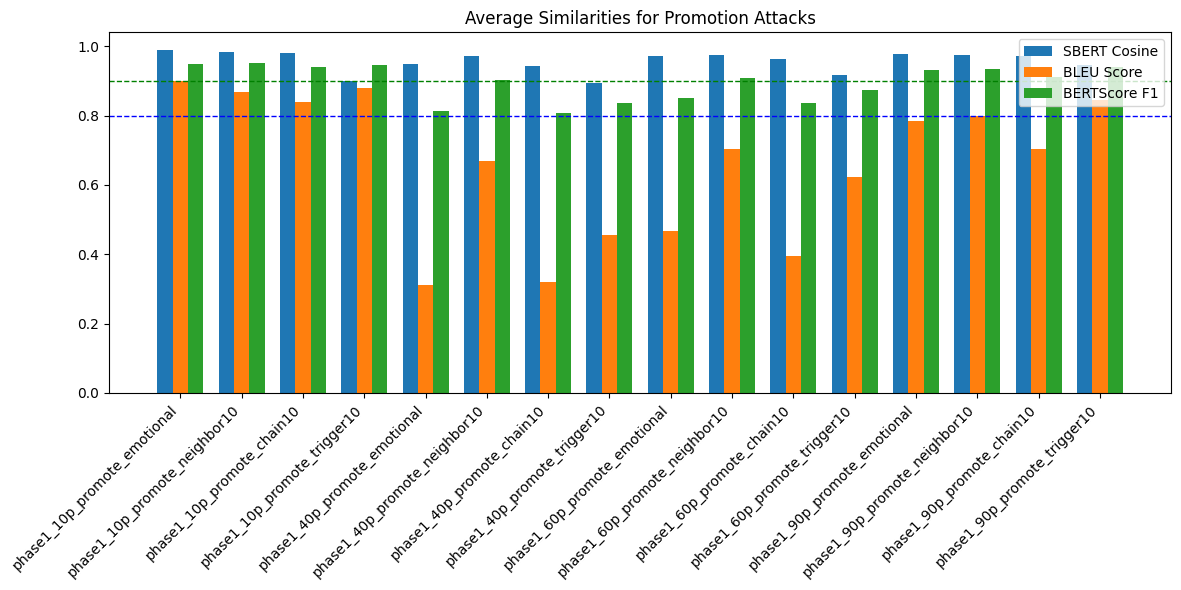

Processing completed. DataFrames saved for the selected attack scenario.


In [ ]:
# Sample 100 items from the dataset
#df_items = df_items.sample(n=100, random_state=42)
adjust_ratio_for_imablanced_ds = 'yes' if ds_name == 'lfm360k' else 'no'
# Check the attack flag to decide whether to use precomputed or generate new attacks
if promote_demote_label.lower() == 'promote':
    # Process for 'promote' attack scenario
    df_promote = apply_phase1_promotions_demotions(
        df_items.copy(),
        direction="promote",
        attack_ratio=attack_ratio,  # 25% of unpopular items
        adjust_ratio_for_imablanced_ds = adjust_ratio_for_imablanced_ds,
        random_seed=42
    )
    # Create the final textual columns for the promoted items
    df_promote = create_final_text_columns(df_promote, direction="promote")

    print("\n==== After PROMOTE Attack ====")
    display(df_promote)    # Analyze and plot results for the 'promote' attack
    analyze_and_plot_phase1_promotions_demotions(df_promote)

    # Save the DataFrame to a compressed .csv.gz file
    compressed_file_path = f'augmented_items_{ds_name}_promote_all_AttackPercents.csv.gz'

    df_promote.to_csv(compressed_file_path, index=False, compression='gzip')
    final_df = df_promote.copy()

elif promote_demote_label.lower() == 'demote':
    # Process for 'demote' attack scenario
    df_demote = apply_phase1_promotions_demotions(
        df_items.copy(),
        direction="demote",
        attack_ratio=attack_ratio,  # 25% of unpopular items
        adjust_ratio_for_imablanced_ds = adjust_ratio_for_imablanced_ds,
        random_seed=42
    )
    # Create the final textual columns for the demoted items
    df_demote = create_final_text_columns(df_demote, direction="demote")

    print("\n==== After DEMOTE Attack ====")
    display(df_demote)
    # Analyze and plot results for the 'demote' attack
    analyze_and_plot_phase1_promotions_demotions(df_demote)

    # Save the DataFrame to a compressed .csv.gz file
    compressed_file_path = f'augmented_items_{ds_name}_demote_all_AttackPercents.csv.gz'
    df_demote.to_csv(compressed_file_path, index=False, compression='gzip')
    final_df = df_demote.copy()
# Print confirmation
print("Processing completed. DataFrames saved for the selected attack scenario.")


In [ ]:
import pandas as pd
from google.colab import files

final_df.to_csv(compressed_file_path, index=False, compression='gzip')
files.download(compressed_file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
compressed_file_path